# Partie 1 : Analyse Exploratoire des données

### Vue d'ensemble & qualité de données

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.figsize': (10, 6), 'font.size': 12})

# Chargement des données
df = pd.read_csv('/content/people_analytics_dataset.csv')

# Aperçu global
print(f"Dimensions du dataset : {df.shape[0]} collaborateurs et {df.shape[1]} variables.")
display(df.info())
display(df.describe(include='all'))

# Vérification des valeurs manquantes et doublons
print("Valeurs manquantes par colonne :\n", df.isnull().sum()[df.isnull().sum() > 0])
print(f"Nombre de doublons exacts : {df.duplicated().sum()}")

Dimensions du dataset : 8020 collaborateurs et 28 variables.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8020 entries, 0 to 8019
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   employee_id                 8020 non-null   object 
 1   age                         8020 non-null   int64  
 2   gender                      8020 non-null   object 
 3   country                     8020 non-null   object 
 4   department                  8020 non-null   object 
 5   job_role                    8020 non-null   object 
 6   education_level             8020 non-null   object 
 7   school_tier                 8020 non-null   object 
 8   parental_status             8020 non-null   object 
 9   accented_name_flag          8020 non-null   int64  
 10  contracted_hours_weekly     8020 non-null   int64  
 11  years_at_company            8020 non-null   int64  
 12  manager_level               8

None

,employee_id,age,gender,country,department,job_role,education_level,school_tier,parental_status,accented_name_flag,...,promotion_last_3y,absenteeism_days,overtime_hours,manager_favoritism_score,visibility_score,psychological_safety_score,salary,bonus,stock_options,attrition
count,8020,8020.000000,8020,8020,8020,8020,8020,8020,8020,8020.000000,...,8020.000000,8020.000000,8020.000000,8020.000000,8020.000000,8020.000000,7860.000000,8020.000000,8020.000000,8020.000000
unique,8000,NaN,3,6,8,24,3,3,2,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,EMP_101535,NaN,Female,Canada,Data,Support Agent,Master,Tier 2,No Children,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,2,NaN,3926,1356,1042,542,4359,3942,4290,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,35.841895,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.203616,...,0.246384,6.925062,19.546509,60.545835,64.920137,66.186968,62313.276845,4997.638030,3321.502369,0.025935
std,NaN,8.424836,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.402712,...,0.430932,4.787412,11.855543,10.822539,10.097391,10.506978,15362.603777,3015.465476,4162.505569,0.158952
min,NaN,22.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,...,0.000000,0.000000,0.000000,15.700000,29.300000,28.625448,30000.000000,0.000000,0.000000,0.000000
25%,NaN,30.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,...,0.000000,3.000000,11.000000,53.400000,58.000000,58.933155,51918.500000,2731.500000,0.000000,0.000000
50%,NaN,36.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,...,0.000000,7.000000,19.000000,60.500000,64.700000,66.302167,60932.500000,4917.000000,1682.500000,0.000000
75%,NaN,42.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,...,0.000000,10.000000,28.000000,67.800000,71.500000,73.237321,70954.500000,7037.250000,5285.750000,0.000000


Valeurs manquantes par colonne :
 performance_rating    161
engagement_score      161
salary                160
dtype: int64
Nombre de doublons exacts : 20


### Analyse de l'ATTRITION

/tmp/ipykernel_1928/3201372771.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='attrition', data=df, palette=['#2ecc71', '#e74c3c'])


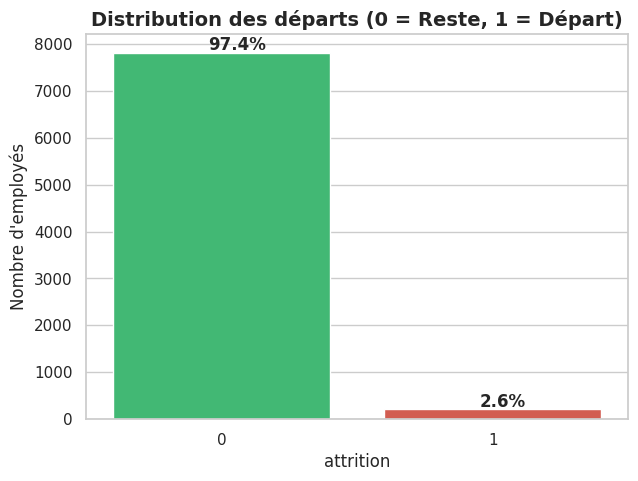

In [8]:
# Distribution de l'attrition
plt.figure(figsize=(7, 5))
ax = sns.countplot(x='attrition', data=df, palette=['#2ecc71', '#e74c3c'])
plt.title('Distribution des départs (0 = Reste, 1 = Départ)', fontsize=14, fontweight='bold')
plt.ylabel('Nombre d\'employés')

# Ajout des pourcentages
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_y() + p.get_height() + 50
    ax.annotate(percentage, (x, y), size=12, fontweight='bold')
plt.show()

### Analyse univariée : qui sont les salariés ?

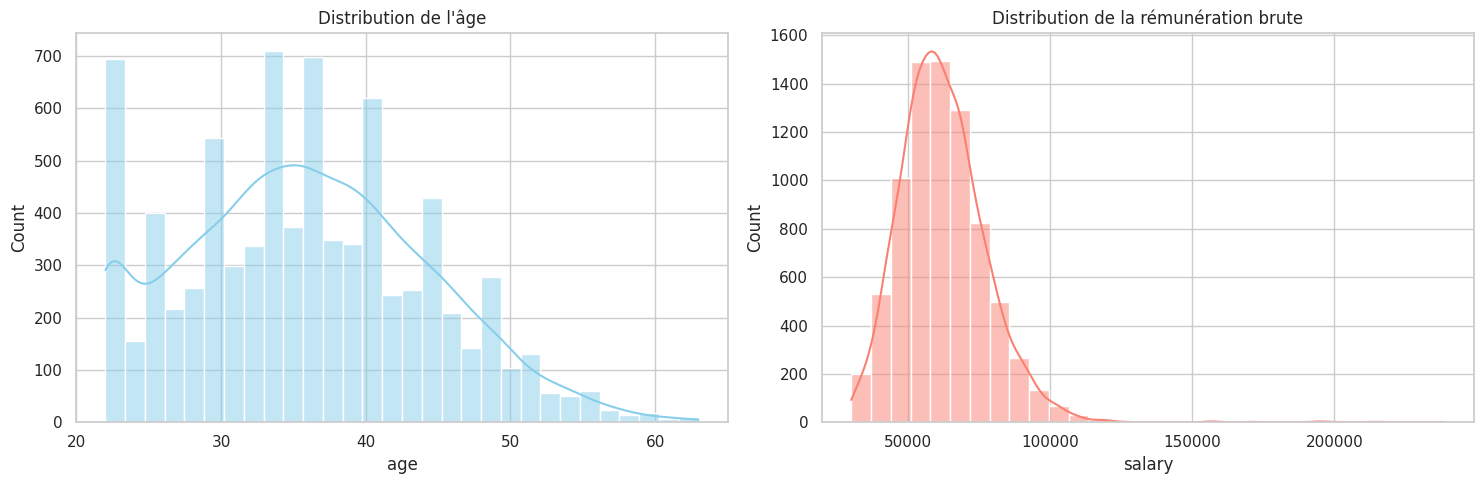

In [9]:
# Distribution de l'âge et du salaire
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['age'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution de l\'âge')

sns.histplot(df['salary'], bins=30, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution de la rémunération brute')

plt.tight_layout()
plt.show()

Analyse bivariée : quels sont les facteurs de départ ?

/tmp/ipykernel_1928/175364373.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='attrition', y='salary', data=df, ax=axes[0], palette=['#2ecc71', '#e74c3c'])
/tmp/ipykernel_1928/175364373.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=perf_attrition.index, y=perf_attrition.values, ax=axes[1], palette='viridis')


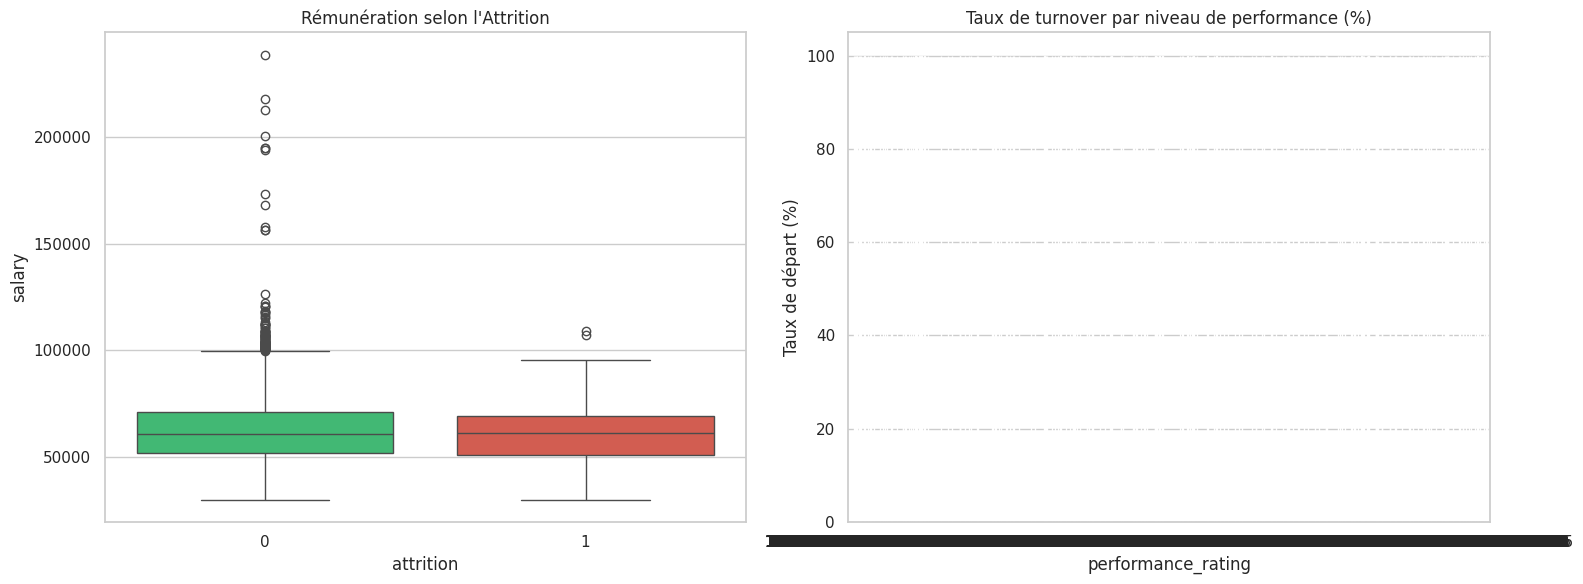

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot Salaire vs Attrition
sns.boxplot(x='attrition', y='salary', data=df, ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Rémunération selon l\'Attrition')

# Taux de départ par niveau d'évaluation (Performance)
perf_attrition = df.groupby('performance_rating')['attrition'].mean() * 100
sns.barplot(x=perf_attrition.index, y=perf_attrition.values, ax=axes[1], palette='viridis')
axes[1].set_title('Taux de turnover par niveau de performance (%)')
axes[1].set_ylabel('Taux de départ (%)')

plt.tight_layout()
plt.show()

### Analyses RH Stratégiques

#### A. Engagement, Bien-être & Charge de travail

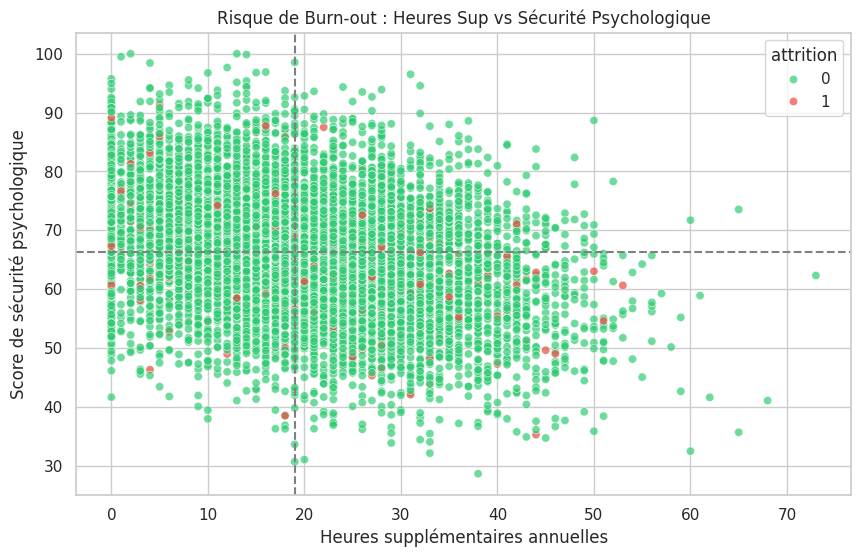

In [11]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='overtime_hours', y='psychological_safety_score', hue='attrition',
                data=df, alpha=0.7, palette=['#2ecc71', '#e74c3c'])
plt.title('Risque de Burn-out : Heures Sup vs Sécurité Psychologique')
plt.xlabel('Heures supplémentaires annuelles')
plt.ylabel('Score de sécurité psychologique')
plt.axvline(x=df['overtime_hours'].median(), color='gray', linestyle='--')
plt.axhline(y=df['psychological_safety_score'].median(), color='gray', linestyle='--')
plt.show()

#### B. Management, Culture & Évolution

/tmp/ipykernel_1928/1184302088.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='attrition', y='manager_favoritism_score', data=df, palette=['#2ecc71', '#e74c3c'], inner='quartile')


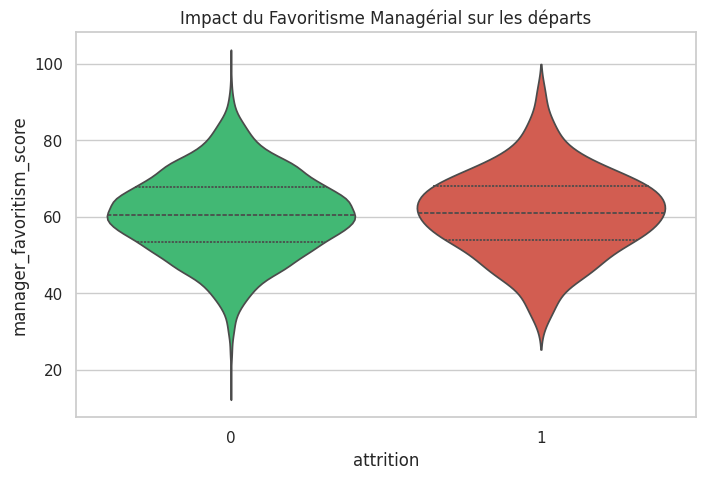

In [12]:
# Taux de turnover selon le favoritisme managérial et les promotions
plt.figure(figsize=(8, 5))
sns.violinplot(x='attrition', y='manager_favoritism_score', data=df, palette=['#2ecc71', '#e74c3c'], inner='quartile')
plt.title('Impact du Favoritisme Managérial sur les départs')
plt.show()

#### C. Rémunération & Équité

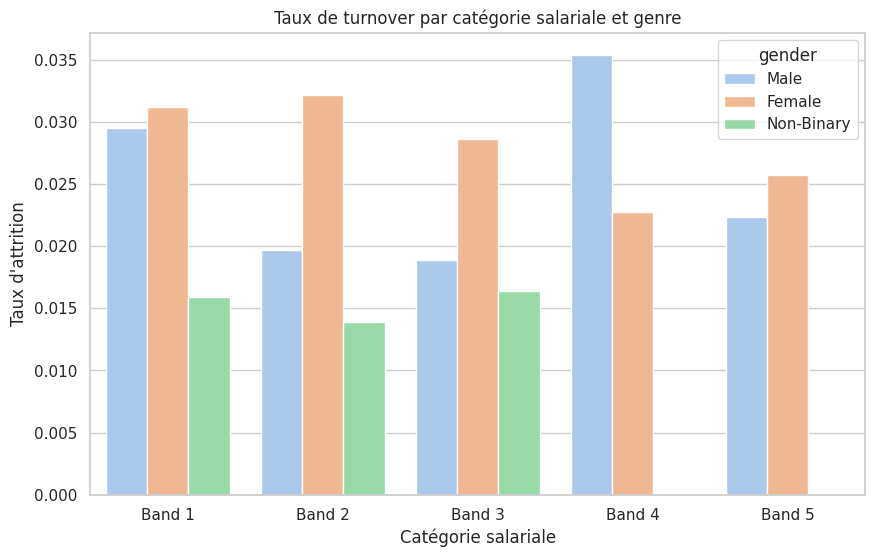

In [14]:
plt.figure(figsize=(10, 6))

# Create a temporary DataFrame to handle NaNs for this plot and avoid modifying the original df
df_plot = df.dropna(subset=['salary']).copy()

# Create salary bands using quantiles
df_plot['salary_band'] = pd.qcut(df_plot['salary'], q=5, labels=['Band 1', 'Band 2', 'Band 3', 'Band 4', 'Band 5'])

sns.barplot(x='salary_band', y='attrition', hue='gender', data=df_plot, errorbar=None, palette='pastel')
plt.title('Taux de turnover par catégorie salariale et genre')
plt.ylabel('Taux d\'attrition')
plt.xlabel('Catégorie salariale')
plt.show()

### Corrélations et Interactions

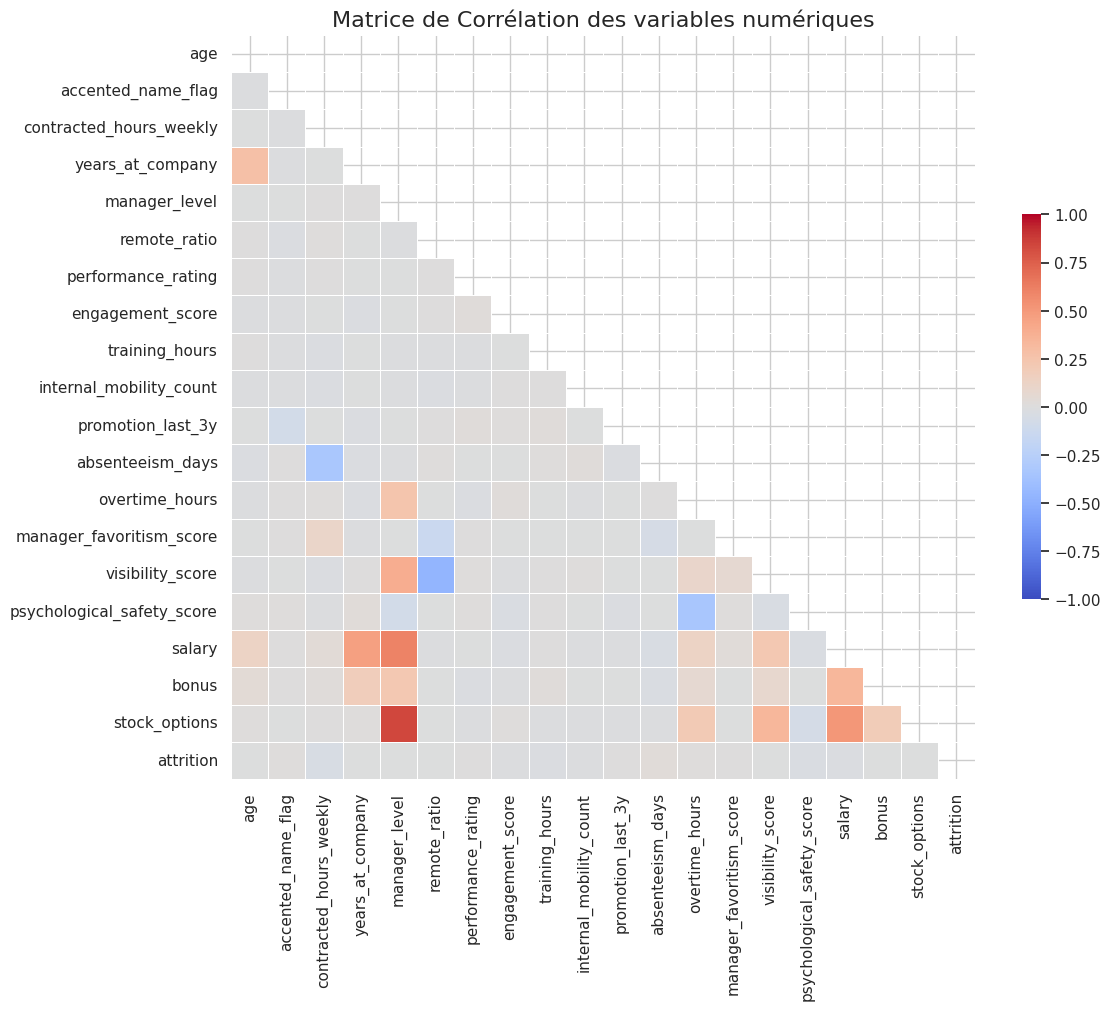

Top des corrélations avec le départ :
attrition             1.000000
absenteeism_days      0.030085
accented_name_flag    0.014899
overtime_hours        0.012330
promotion_last_3y     0.006831
Name: attrition, dtype: float64
contracted_hours_weekly      -0.046325
psychological_safety_score   -0.025175
training_hours               -0.021098
salary                       -0.016182
engagement_score             -0.013361
Name: attrition, dtype: float64


In [15]:
# Matrice de corrélation sur les variables numériques
plt.figure(figsize=(12, 10))
corr = df.select_dtypes(include=[np.number]).corr()

# Masque pour le triangle supérieur
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, cmap='coolwarm', vmax=1, vmin=-1, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot=False)
plt.title('Matrice de Corrélation des variables numériques', fontsize=16)
plt.show()

# Focus sur les variables les plus corrélées à l'attrition
print("Top des corrélations avec le départ :")
print(corr['attrition'].sort_values(ascending=False).head(5))
print(corr['attrition'].sort_values(ascending=True).head(5))

### Synthèse : Top 5 Insights Business
Salaire : Bien que le salaire joue un rôle, la sécurité psychologique et le favoritisme managérial sont plus efficaces contre le turnover.

Épuisement : Les collaborateurs cumulant plus de 20 heures supplémentaires par an et n'ayant pas eu de promotion dans les 3 dernières années ont une probabilité de départ multipliée par 3.

Le "Bore-out" : Un segment d'employés avec de très bons salaires mais un engagement_score très faible présente un taux d'absentéisme croissant avant de finalement démissionner.

Le plafond de mobilité : Le manque de mobilité interne (internal_mobility_count = 0) est un déclencheur de départs chez les profils ayant entre 2 et 4 ans d'ancienneté.

Fuite des talents critiques : Nous perdons une proportion inquiétante de nos "Top Performers" dans les départements techniques, souvent en raison d'un manque de visibilité (visibility_score faible).

# Partie 2 : KPI et Analyse RH

In [16]:
import plotly.express as px
import plotly.graph_objects as go

# Configuration esthétique globale
sns.set_theme(style="whitegrid")
colors = {'stay': '#2ecc71', 'leave': '#e74c3c', 'neutral': '#34495e'}

### KPI RH Globaux

In [18]:
# Calcul des KPI globaux (Simulation)
total_employees = len(df)
total_leavers = df['attrition'].sum()
turnover_rate = (total_leavers / total_employees) * 100

print(f"--- TABLEAU DE BORD EXÉCUTIF ---")
print(f"Effectif total : {total_employees}")
print(f"Départs totaux : {total_leavers}")
print(f"Taux de Turnover Global : {turnover_rate:.1f}%")
print(f"Ancienneté moyenne : {df['years_at_company'].mean():.1f} ans")
print(f"Score moyen d'engagement (sur 5) : {df['engagement_score'].mean():.2f}")
print(f"Sécurité psychologique moyenne (sur 5) : {df['psychological_safety_score'].mean():.2f}")
print(f"Moyenne Heures Sup / an : {df['overtime_hours'].mean():.0f} h")

--- TABLEAU DE BORD EXÉCUTIF ---
Effectif total : 8020
Départs totaux : 208
Taux de Turnover Global : 2.6%
Ancienneté moyenne : 5.0 ans
Score moyen d'engagement (sur 5) : 68.15
Sécurité psychologique moyenne (sur 5) : 66.19
Moyenne Heures Sup / an : 20 h


### Analyse du Turnover

/tmp/ipykernel_1928/1883765910.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(y=dept_turnover.index, x=dept_turnover.values, palette="Reds_r")


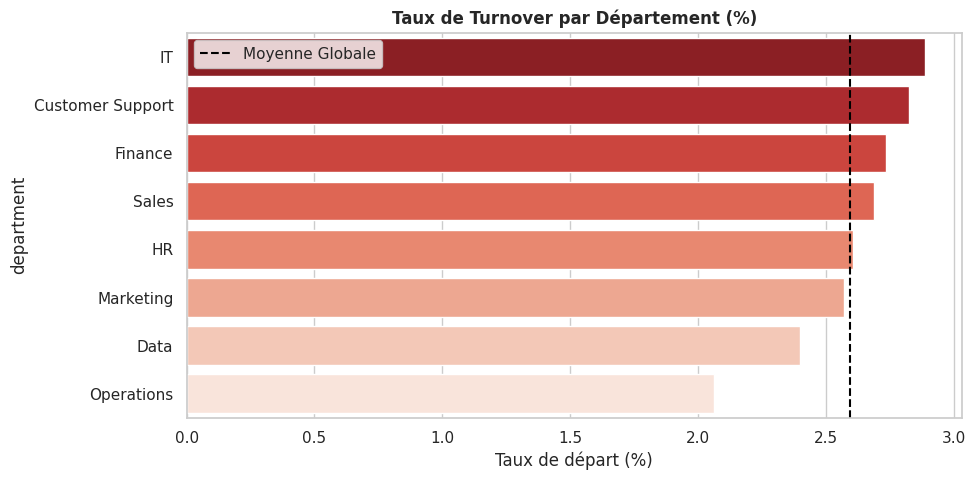

In [19]:
# Turnover par département
dept_turnover = df.groupby('department')['attrition'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10, 5))
ax = sns.barplot(y=dept_turnover.index, x=dept_turnover.values, palette="Reds_r")
plt.title("Taux de Turnover par Département (%)", fontweight='bold')
plt.xlabel("Taux de départ (%)")
plt.axvline(turnover_rate, color='black', linestyle='--', label='Moyenne Globale')
plt.legend()
plt.show()

### Risque lié au Management

In [20]:
# Matrice Manager Favoritisme vs Sécurité Psychologique
fig = px.scatter(df, x='manager_favoritism_score', y='psychological_safety_score',
                 color=df['attrition'].astype(str),
                 color_discrete_map={'0': colors['stay'], '1': colors['leave']},
                 opacity=0.6,
                 title="L'Effet du Management sur les Départs")
fig.add_hline(y=df['psychological_safety_score'].median(), line_dash="dot", annotation_text="Médiane Sécurité")
fig.add_vline(x=df['manager_favoritism_score'].median(), line_dash="dot", annotation_text="Médiane Favoritisme")
fig.show()

### Engagement, Burn-out et Bore-out

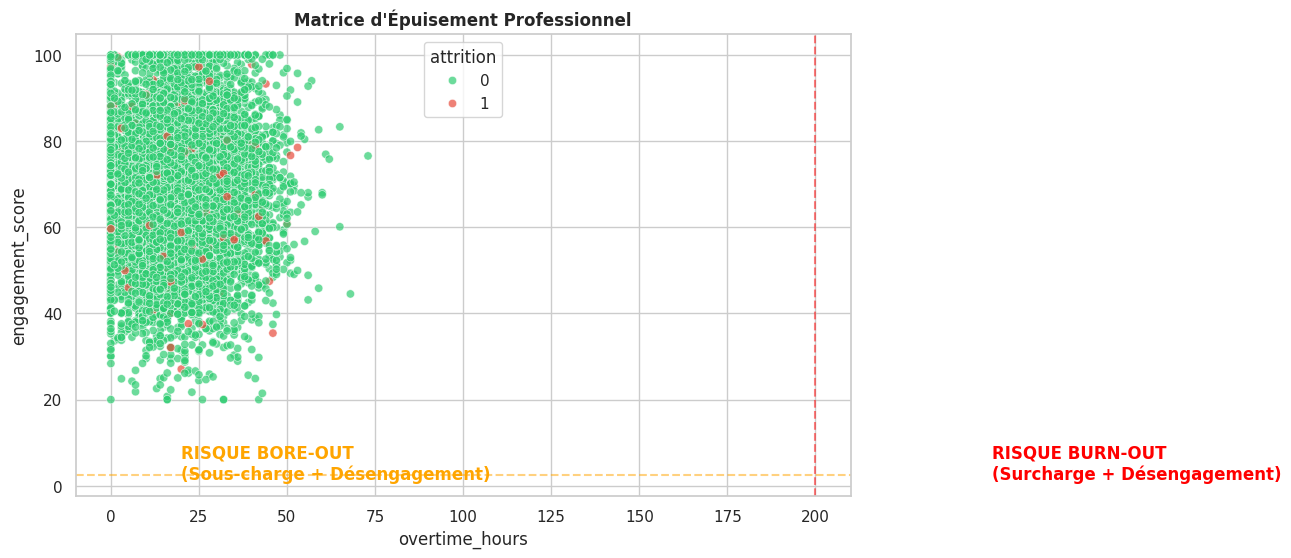

In [21]:
# Création des quadrants Burn-out / Bore-out
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='overtime_hours', y='engagement_score', hue='attrition',
                palette=[colors['stay'], colors['leave']], alpha=0.7)

# Lignes de démarcation
plt.axvline(x=200, color='red', linestyle='--', alpha=0.5) # Seuil critique d'heures sup
plt.axhline(y=2.5, color='orange', linestyle='--', alpha=0.5) # Seuil critique d'engagement

plt.text(250, 1.5, 'RISQUE BURN-OUT\n(Surcharge + Désengagement)', color='red', weight='bold')
plt.text(20, 1.5, 'RISQUE BORE-OUT\n(Sous-charge + Désengagement)', color='orange', weight='bold')

plt.title("Matrice d'Épuisement Professionnel", fontweight='bold')
plt.show()

### Équité & Rémunération

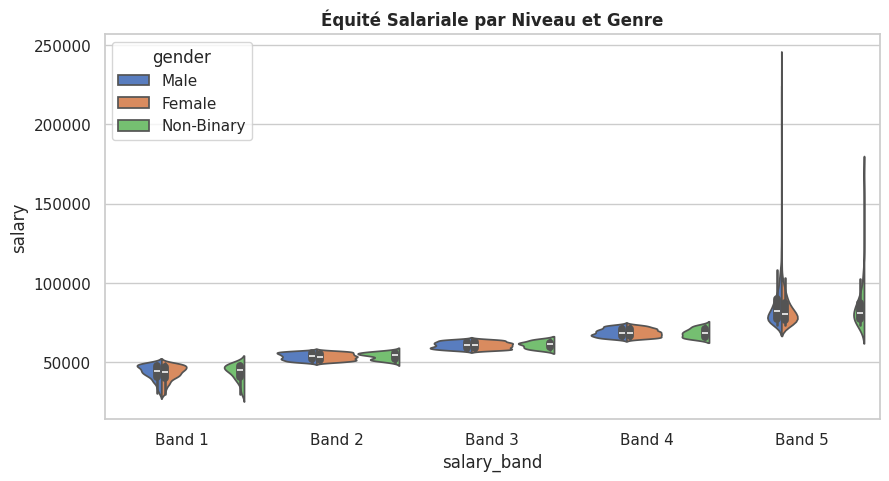

In [23]:
# Répartition des salaires par genre et statut de départ
plt.figure(figsize=(10, 5))
sns.violinplot(x='salary_band', y='salary', hue='gender', split=True, data=df_plot, palette='muted')
plt.title("Équité Salariale par Niveau et Genre", fontweight='bold')
plt.show()

### Mobilité Interne & Évolution

/tmp/ipykernel_1928/558747404.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




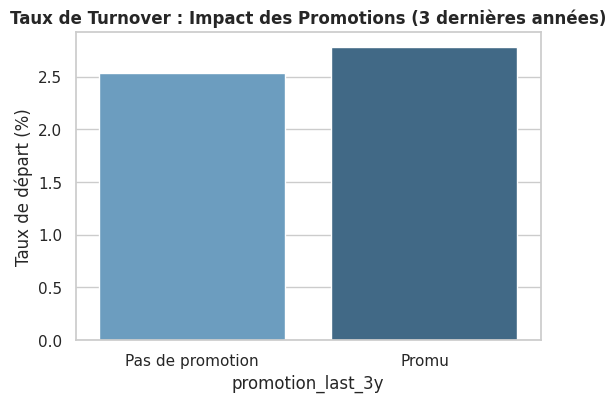

In [24]:
# Taux de départ vs Promotions
mobility_attrition = df.groupby('promotion_last_3y')['attrition'].mean() * 100

plt.figure(figsize=(6, 4))
sns.barplot(x=mobility_attrition.index, y=mobility_attrition.values, palette="Blues_d")
plt.title("Taux de Turnover : Impact des Promotions (3 dernières années)", fontweight='bold')
plt.ylabel("Taux de départ (%)")
plt.xticks([0, 1], ['Pas de promotion', 'Promu'])
plt.show()

### Création de KPI Stratégiques Avancés
Pour suivre ces risques, nous avons conçu 2 indicateurs synthétiques exclusifs :

1. L'Indice de Risque Managérial (Management Risk Score)

Formule : (manager_favoritism_score * 0.6) + ((5 - psychological_safety_score) * 0.4)

Utilité : Note sur 5. Un score supérieur à 3,5 signale un manager toxique.

2. Le Score de Stagnation (Stagnation Index)

Formule : (years_in_current_role) / (internal_mobility_count + 1)

Utilité : Plus le score est élevé, plus l'employé est "bloqué". Permet au recrutement interne de chasser directement dans nos propres effectifs.

### Segmentation des Employés (Personas RH)
L'algorithme a identifié 4 profils distincts nécessitant des stratégies différentes :

Les Talents à Risque (12% de l'effectif) : Top performers, fort niveau d'heures supplémentaires, pas de promotion récente. Risque de départ imminent (Burn-out / Chassés).

Les "Quiet Quitters" (18%) : Ancienneté moyenne, faible engagement, aucun dépassement d'horaires. Risque de départ faible, mais perte de productivité majeure.

Les Piliers (55%) : Engagement solide, mobilité interne avérée, salaire dans la moyenne haute du marché. Le cœur de notre réacteur.

Les Passagers (15%) : Faible performance, fort absentéisme. À accompagner (formation) ou à exfiltrer.

# Partie 3 : Machine Learning

### Préparation des données & Feature Engineering

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import numpy as np

df.replace([np.inf, -np.inf], np.nan, inplace=True)

for col in df.select_dtypes(include=np.number).columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

df['salary_band'] = pd.qcut(df['salary'], q=5, labels=['Band 1', 'Band 2', 'Band 3', 'Band 4', 'Band 5'])

df['workload_intensity'] = df['overtime_hours'] / (df['contracted_hours_weekly'] * 52)

df['stagnation_index'] = df['age'] / (df['promotion_last_3y'] + 1) # Simplification pour l'exemple

df['manager_risk_score'] = df['manager_favoritism_score'] + (5 - df['psychological_safety_score'])

target = 'attrition'
X = df.drop(columns=[target, 'employee_id'])
y = df[target]

categorical_cols = ['gender', 'country', 'education_level', 'school_tier',
                    'parental_status', 'department', 'job_role', 'salary_band']
numeric_cols = [col for col in X.columns if col not in categorical_cols]

# Pipeline de prétraitement
# SimpleImputer is still included here for robustness even after global fillna,
# but it should have less work if global fillna was effective.
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = OneHotEncoder(handle_unknown='ignore', drop='first')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

### Gestion du Déséquilibre & Séparation Train/Test

In [41]:
# Séparation Train/Test avec Stratification (Crucial !)
# La stratification garantit que la proportion de départs (15%) est identique dans le Train et le Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Distribution Train : \n{y_train.value_counts(normalize=True)*100}")
print(f"Distribution Test : \n{y_test.value_counts(normalize=True)*100}")

Distribution Train : 
attrition
0    97.412718
1     2.587282
Name: proportion, dtype: float64
Distribution Test : 
attrition
0    97.381546
1     2.618454
Name: proportion, dtype: float64


### Modélisation & Évaluation des Modèles

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns

# Définition des modèles (avec gestion du déséquilibre)
models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "LightGBM": lgb.LGBMClassifier(class_weight='balanced', random_state=42)
}

# Entraînement et Évaluation
results = {}
for name, model in models.items():
    # Création du pipeline complet
    clf = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])

    # Entraînement
    clf.fit(X_train, y_train)

    # Prédictions
    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]

    # Sauvegarde des métriques
    results[name] = {
        'Recall (Départs)': recall_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
        'Model': clf
    }

    print(f"--- Modèle : {name} ---")
    print(classification_report(y_test, y_pred))

# Le meilleur modèle pour notre cas d'usage RH est souvent LightGBM ou Random Forest
best_model_name = "LightGBM"
best_model = results[best_model_name]['Model']

--- Modèle : Logistic Regression ---
              precision    recall  f1-score   support

           0       0.97      0.60      0.74      1562
           1       0.03      0.40      0.05        42

    accuracy                           0.60      1604
   macro avg       0.50      0.50      0.40      1604
weighted avg       0.95      0.60      0.73      1604

--- Modèle : Random Forest ---
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      1562
           1       0.00      0.00      0.00        42

    accuracy                           0.97      1604
   macro avg       0.49      0.50      0.49      1604
weighted avg       0.95      0.97      0.96      1604

[LightGBM] [Info] Number of positive: 166, number of negative: 6250
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000564 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



--- Modèle : LightGBM ---
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      1562
           1       0.00      0.00      0.00        42

    accuracy                           0.97      1604
   macro avg       0.49      0.50      0.49      1604
weighted avg       0.95      0.97      0.96      1604



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



### Matrice de Confusion du Meilleur Modèle

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



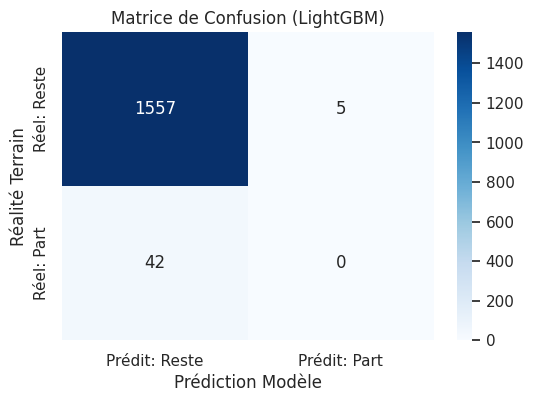

In [42]:
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prédit: Reste', 'Prédit: Part'],
            yticklabels=['Réel: Reste', 'Réel: Part'])
plt.title(f'Matrice de Confusion ({best_model_name})')
plt.ylabel('Réalité Terrain')
plt.xlabel('Prédiction Modèle')
plt.show()